---
## 🎁 가산점 신청 (선택)

가산점을 받으려면 아래 항목 중 시도한 것을 **체크**하고, **해당 코드 셀 번호**를 적어주세요.
신청하지 않은 항목은 채점하지 않습니다.

### ✅ A. 알고리즘의 다양성
- 사용 알고리즘 (5): Logistic Regression, Random Forest, Gradient Boosting, SVM, MLP
- 해당 셀: 10번

### ✅ B. Hyperparameter 탐색의 다양성
- 각 알고리즘별 GridSearchCV 적용 (LR: C / RF: n_estimators, max_depth / SVM: C, kernel / GB: learning_rate, n_estimators / MLP: hidden_layer_sizes, activation)
- 해당 셀: 17~22번

### ✅ C. 모델 성능 평가
- Accuracy, Sensitivity, Specificity, F1, ROC-AUC, MCC 6가지 지표 사용
- 최종 모델 선택 기준: MCC (class imbalance에 강건한 지표)
- 해당 셀: 22번, 23번, 24~31번(시각화)

### ✅ D. 모델 개발 과정 시각화
- 막대 그래프: 모델별 성능 비교
- ROC Curve: 모든 모델 비교
- Confusion Matrix: 최종 모델
- Learning Curve: 과적합 확인
- 해당 셀: 23~31번

# 기말고사 Template 2 — Machine Learning Model Pipeline

**이름:** ____장다예____ &nbsp; **학번:** _______20251281_______ &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **5. 모델 학습 알고리즘** | 15점 | 기계학습 알고리즘을 몇 종 사용했는지? |
| **6. Hyperparameter 탐색** | 15점 | 기계학습 알고리즘 별로 hyperparameter를 어떻게 최적화 시켰는지? |
| **7. 결과 정리 & 시각화** | 15점 | 최종 모델을 선택한 기준 및 모델 개발 과정을 설명하는 시각화 자료 |
| **8. 모델 저장 & 새 분자 예측** | 5점 | 모델을 저장한 후, 새로운 분자 구조를 예측할 수 있도록 정리. |

## 📁 입력 / 출력
- **입력**: Template 1에서 만든 `final_dataset_descriptors.csv`
- **출력**: 
  - `experiment_results.csv` — 모든 실험 결과 표
  - `experiment_best.csv` — 모델별 베스트만
  - `model_best.joblib` — 최고 모델 저장 파일 (features + scaler + model)

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_cancer = pd.read_csv("final_dataset_descriptors.csv")
print("Data shape:", df_cancer.shape)
print(df_cancer["label"].value_counts())
df_cancer.head()

Data shape: (397, 309)
label
0.0    238
1.0    159
Name: count, dtype: int64


,Chemical_Name,SMILES,clean_smiles,label,MolWt,MolLogP,TPSA,RingCount,NumHDonors,NumHAcceptors,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,Divinylbenzene,"*C=C.C=CC1=CC=CC=C1 |c:6,8,t:4,m:0:8.6|",*C=C.C=Cc1ccccc1,0.0,131.198,3.00880,0.00,1,0,0,...,0,0,0,0,0,1,1,0,1,1
1,Bromoform,BrC(Br)Br,BrC(Br)Br,0.0,252.731,2.45470,0.00,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Dibromoacetonitrile,BrC(Br)C#N,N#CC(Br)Br,1.0,198.845,1.62588,23.79,0,0,1,...,0,0,0,0,1,0,0,0,0,0
3,"2,2',3,3',4,4',5,5',6,6'-Decabromodiphenyl ether",BrC1=C(Br)C(Br)=C(OC2=C(Br)C(Br)=C(Br)C(Br)=C2...,Brc1c(Br)c(Br)c(Oc2c(Br)c(Br)c(Br)c(Br)c2Br)c(...,0.0,959.171,11.10390,9.23,2,0,1,...,1,0,0,0,0,1,1,1,1,0
4,"1,2-Dibromo-2,4-dicyanobutane",BrCC(Br)(CCC#N)C#N,N#CCCC(Br)(C#N)CBr,0.0,265.936,2.34236,47.58,0,0,2,...,0,0,0,0,1,0,0,0,0,0


In [3]:
import importlib
if importlib.util.find_spec("xgboost") is None:
    %pip install -q xgboost

In [4]:
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_classif
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.neural_network import MLPClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve
)

In [5]:
# 1. 모델 학습에 사용할 10가지 주요 물리화학적 디스크립터(Physicochemical Descriptors) 변수 지정
physchem_cols = [
    'MolWt',
    'MolLogP',
    'TPSA',
    'RingCount',
    'NumHDonors',
    'NumHAcceptors',
    'NumRotatableBonds',
    'FractionCSP3',
    'NumAromaticRings',
    'HeavyAtomCount'
]

# 2. 데이터프레임에서 'FP_'로 시작하는 Morgan 핑거프린트 컬럼명을 자동으로 탐색하여 리스트화
fp_cols = [
    c for c in df_cancer.columns 
    if c.startswith('FP_')
]

# 3. 데이터프레임에서 'MACCS_'로 시작하는 MACCS 키 컬럼명을 자동으로 탐색하여 리스트화
maccs_cols = [
    c for c in df_cancer.columns 
    if c.startswith('MACCS_')
]

# 4. 물리화학적 특성, Morgan 핑거프린트, MACCS 키를 결합하여 머신러닝 모델의 최종 독립 변수(Feature) 리스트 구축
feature_cols = (
    physchem_cols
    + fp_cols
    + maccs_cols
)

In [6]:
# 1. 모델이 학습할 독립 변수(X, 특성 데이터셋) 그룹
X = df_cancer[feature_cols]

# 2. 모델이 예측할 타겟 변수(y, 종속 변수)를 0 또는 1로 변환
y = df_cancer["label"].astype(int)

# 3. 최종 데이터셋의 구조
print(X.shape)

# 4. 타겟 변수(y)의 클래스별 데이터 빈도수를 재확인하여 데이터 불균형 상태 재점검
print(y.value_counts())

(397, 305)
label
0    238
1    159
Name: count, dtype: int64


In [7]:
# 전체 데이터셋을 80:20 비율로 학습용(Train)과 검증용(Test) 데이터셋으로 분할
# stratify=y 설정을 통해 학습 데이터와 테스트 데이터의 발암성(0/1) 라벨 비율을 원본과 동일하게 유지
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y
)

# 분할이 완료된 학습용 독립변수(X_train)와 테스트용 독립변수(X_test)의 데이터 크기(행, 열) 확인
print(X_train.shape)
print(X_test.shape)

(317, 305)
(80, 305)


In [8]:
#학습 데이터셋(X_train) 내에 텍스트 형태의 문자열(object) 변수가 남아있는지 컬럼명 확인
X_train.select_dtypes(include="object").columns

Index([], dtype='str')

In [9]:
# 분산이 0.01 이하인(값이 거의 일정한) 변수를 제거
var_selector = VarianceThreshold(
    threshold=0.01
)

# 학습 데이터셋(X_train)의 분산을 계산, 임계값 미만인 변수들 제거(transform)
X_train_var = var_selector.fit_transform(
    X_train
)

# 테스트 데이터셋(X_test)도 학습 데이터셋과 동일한 변수(컬럼) 구조를 가지도록 일관되게 변환
# 테스트 데이터를 기준으로 분산을 새로 계산하지 않음으로써 데이터 누수(Data Leakage)를 방지
X_test_var = var_selector.transform(
    X_test
)

print(X_train_var.shape)

(317, 279)


### 사용한 알고리즘: Logistic Regression, Random Forest, Gradient Boosting, SVM, MLP  

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest":       RandomForestClassifier(),
    "Gradient Boosting":   GradientBoostingClassifier(),
    "SVM":                 SVC(probability=True),
    "MLP":                 MLPClassifier(max_iter=1000),
}

In [11]:
# 5가지 머신러닝 모델의 학습, 예측, 평가

# Sensitivity = Recall (양성을 얼마나 잘 잡는지)
# Specificity  = 음성을 얼마나 잘 잡는지

# 1) True Negative (TN) → 정상적으로 맞춤
# 2) False Positive (FP) → 틀린 양성 예측 (암 아닌데 암으로 예측)
# 3) False Negative (FN) → 놓친 케이스 (암인데 암 아니라고 예측)
# 4) True Positive (TP) → 정상적으로 맞춤

results = []

for name, model in models.items():

    # 훈련
    model.fit(X_train, y_train)

    # 예측
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    # confusion matrix에서 TN, FP, FN, TP 꺼내기
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    results.append({
        "Model":       name,
        "Accuracy":    accuracy_score(y_test, pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1":          f1_score(y_test, pred),
        "ROC-AUC":     roc_auc_score(y_test, prob),
        "MCC":         matthews_corrcoef(y_test, pred),
    })

basic_result = pd.DataFrame(results)
basic_result.sort_values("F1", ascending=False)

,Model,Accuracy,Sensitivity,Specificity,F1,ROC-AUC,MCC
4,MLP,0.5875,0.56250,0.604167,0.521739,0.602865,0.163761
0,Logistic Regression,0.6000,0.53125,0.645833,0.515152,0.590495,0.175491
2,Gradient Boosting,0.5750,0.43750,0.666667,0.451613,0.653646,0.105409
1,Random Forest,0.6375,0.34375,0.833333,0.431373,0.671224,0.203860
3,SVM,0.6000,0.00000,1.000000,0.000000,0.416667,0.000000


In [12]:
%whos

Variable                     Type                 Data/Info
-----------------------------------------------------------
GradientBoostingClassifier   ABCMeta              <class 'sklearn.ensemble.<...>dientBoostingClassifier'>
GridSearchCV                 ABCMeta              <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
LogisticRegression           type                 <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
MLPClassifier                ABCMeta              <class 'sklearn.neural_ne<...>erceptron.MLPClassifier'>
Pipeline                     ABCMeta              <class 'sklearn.pipeline.Pipeline'>
RandomForestClassifier       ABCMeta              <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SVC                          ABCMeta              <class 'sklearn.svm._classes.SVC'>
SelectKBest                  ABCMeta              <class 'sklearn.feature_s<...>e_selection.SelectKBest'>
StandardScaler               type                 <class 'sklearn.preproc

[[48  0]
 [32  0]]


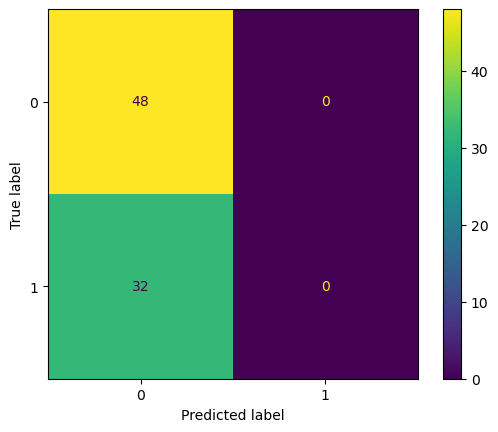

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
#SVM 모델의 성능이(Sensitivity, F1, MCC) 0으로 나타난 원인을 확인하기 위해 confusion matrix를 분석
# -> 모델이 모든 샘플을 음성 클래스(0)로만 예측하고 있었음

# SVM 예측
y_pred_svm = models["SVM"].predict(X_test)
# confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0,1]
)

disp.plot()
plt.show()

In [14]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True
)

cv_result = []

# 정의된 머신러닝 모델들을 순회하며 5-Fold 교차 검증 일괄 수행
for name, model in models.items():

    # 2. 지정된 모델과 평가 지표(F1-Score)를 바탕으로 5회 반복 검증 수행하여 점수 배열 반환
    #불균형 데이터에서 양성과 음성 클래스의 성능을 균형 있게 평가하기 위해 F1-score를 사용함
    score = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="f1"
    )

    # 3. 5번의 테스트 결과물로부터 평균과 표준편차를 계산하여 리스트에 추가
    cv_result.append({

        "Model": name,

        # F1-Score의 평균 (모델의 종합적인 예측 성능 지표)
        "CV_mean":
        score.mean(),

        # F1-Score의 표준편차 (모델의 데이터에 따른 성능 안정성/기복 지표)
        "CV_std":
        score.std()

    })
    

cv_result = pd.DataFrame(cv_result)

cv_result.sort_values(
    "CV_mean",
    ascending=False
)

,Model,CV_mean,CV_std
2,Gradient Boosting,0.526230,0.048763
4,MLP,0.509250,0.077385
0,Logistic Regression,0.492066,0.055263
1,Random Forest,0.458347,0.092800
3,SVM,0.000000,0.000000


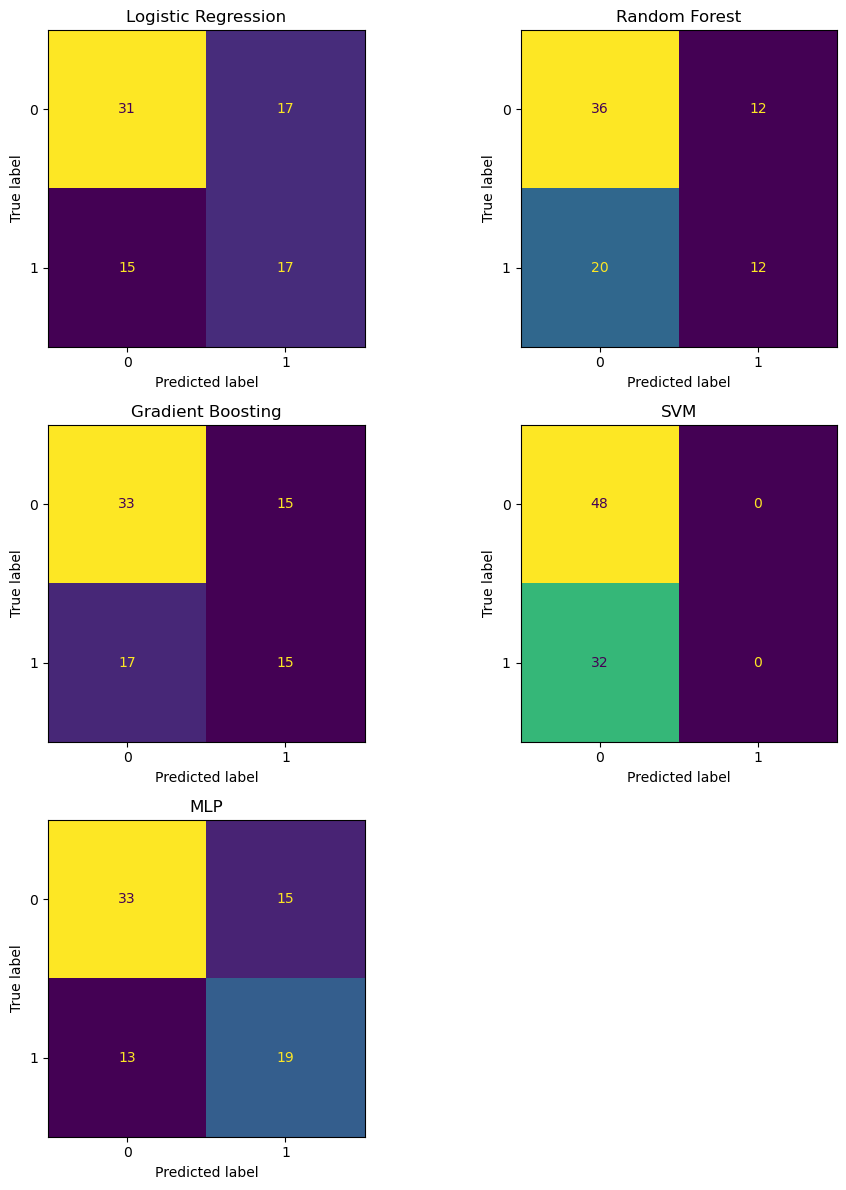

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import math
#각 알고리즘별 구체적인 오답 패턴을 한 화면에서 직관적으로 비교 분석하기 위함
models_list = list(models.items())

n_cols = 2
n_rows = math.ceil(len(models_list) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))

axes = axes.flatten()

for i, (name, model) in enumerate(models_list):

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=axes[i], colorbar=False)

    axes[i].set_title(name)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [16]:
# 1. 5-폴드 계층적 교차 검증(Stratified K-Fold) 객체 생성 (클래스 비율 유지)
cv = StratifiedKFold(n_splits=5)

cv_result = []

# 정의된 머신러닝 모델들을 순회하며 5-Fold 교차 검증을 통한 과적합 방지 검증 수행
for name, model in models.items():

    # 2. 각 모델별로 5번의 검증을 수행하고, 각 회차의 F1-Score 값을 배열로 반환
    score = cross_val_score(model, X, y, cv=cv, scoring="f1")

    # 3. 5번의 결과로부터 산출된 통계치(평균과 표준편차)를 딕셔너리 형태로 저장
    cv_result.append({
        "Model":   name,
        "CV_mean": score.mean(), # 5회 교차 검증 F1-Score의 평균값 (기대 성능)
        "CV_std":  score.std(),  # 5회 교차 검증 F1-Score의 표준편차 (성능의 안정성/편차)
    })

# 4. 수집된 결과 리스트를 비교 분석을 위해 Pandas 데이터프레임으로 변환
cv_result = pd.DataFrame(cv_result)

# 5. 교차 검증 F1-Score 평균(CV_mean)이 가장 높은 순서대로 내림차순 정렬하여 최적의 일반화 모델 식별
cv_result.sort_values("CV_mean", ascending=False)

,Model,CV_mean,CV_std
0,Logistic Regression,0.500749,0.092993
4,MLP,0.433833,0.089346
2,Gradient Boosting,0.376737,0.098807
1,Random Forest,0.359002,0.152773
3,SVM,0.000000,0.000000


## Hyperparameter 탐색

각 알고리즘별로 중요한 hyperparameter를 GridSearchCV로 탐색.

알고리즘의 기본 매개변수로 발생할 수 있는 성능 편향과 과적합을 방지하고, 화합물 데이터셋 고유의 차원 및 클래스 불균형 특성에 최적화된 모델의 최대 일반화 성능을 확보하고자 교차 검증 기반의 GridSearchCV 탐색을 수행함.

In [17]:
# Logistic Regression — 규제 강도 C 탐색
# C가 작을수록 규제가 강해서 단순한 모델

lr_params = {"C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=5,
    scoring="f1"
)
grid_lr.fit(X_train, y_train)

print("LR 최적 파라미터:", grid_lr.best_params_)
print("LR 최적 CV F1:", round(grid_lr.best_score_, 4))

LR 최적 파라미터: {'C': 100}
LR 최적 CV F1: 0.5774


In [18]:
# Random Forest — 트리 개수(n_estimators)와 최대 깊이(max_depth) 탐색

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
)


rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
}


grid_rf = GridSearchCV(
    RandomForestClassifier(),
    rf_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)


print("RF 최적 파라미터:", grid_rf.best_params_)
print("RF 최적 CV F1:", round(grid_rf.best_score_, 4))

RF 최적 파라미터: {'max_depth': None, 'n_estimators': 100}
RF 최적 CV F1: 0.5177


In [19]:
# SVM — 규제 강도(C)와 커널(kernel) 탐색

svm_params = {
    "C":      [0.1, 0.3, 1, 3, 10],
    "kernel": ["linear", "rbf"],
}

grid_svm = GridSearchCV(
    SVC(probability=True),
    svm_params,
    cv=5,
    scoring="f1"
)
grid_svm.fit(X_train, y_train)

print("SVM 최적 파라미터:", grid_svm.best_params_)
print("SVM 최적 CV F1:", round(grid_svm.best_score_, 4))

SVM 최적 파라미터: {'C': 1, 'kernel': 'linear'}
SVM 최적 CV F1: 0.5894


In [20]:
# Gradient Boosting — 학습률(learning_rate)과 트리 개수(n_estimators) 탐색

gb_params = {
    "learning_rate": [0.05, 0.1, 0.2],
    "n_estimators":  [50, 100, 200],
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(),
    gb_params,
    cv=5,
    scoring="f1"
)
grid_gb.fit(X_train, y_train)

print("GB 최적 파라미터:", grid_gb.best_params_)
print("GB 최적 CV F1:", round(grid_gb.best_score_, 4))

GB 최적 파라미터: {'learning_rate': 0.2, 'n_estimators': 100}
GB 최적 CV F1: 0.4817


In [21]:
# MLP — 은닉층 구조(hidden_layer_sizes)와 활성화 함수(activation) 탐색

mlp_params = {
    "hidden_layer_sizes": [(64,), (128,), (64, 64)],
    "activation":         ["relu", "tanh"],
}

grid_mlp = GridSearchCV(
    MLPClassifier(max_iter=1000),
    mlp_params,
    cv=5,
    scoring="f1"
)
grid_mlp.fit(X_train, y_train)

print("MLP 최적 파라미터:", grid_mlp.best_params_)
print("MLP 최적 CV F1:", round(grid_mlp.best_score_, 4))

MLP 최적 파라미터: {'activation': 'relu', 'hidden_layer_sizes': (128,)}
MLP 최적 CV F1: 0.5674


In [22]:
# 각 GridSearch에서 찾은 best_estimator로 테스트 셋 성능을 다시 측정

best_models = {
    "Logistic Regression": grid_lr.best_estimator_,
    "Random Forest":       grid_rf.best_estimator_,
    "SVM":                 grid_svm.best_estimator_,
    "Gradient Boosting":   grid_gb.best_estimator_,
    "MLP":                 grid_mlp.best_estimator_,
}

tuned_results = []

for name, model in best_models.items():

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    tuned_results.append({
        "Model":       name,
        "Accuracy":    accuracy_score(y_test, pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1":          f1_score(y_test, pred),
        "ROC-AUC":     roc_auc_score(y_test, prob),
        "MCC":         matthews_corrcoef(y_test, pred),
    })

tuned_df = pd.DataFrame(tuned_results)
tuned_df.sort_values("MCC", ascending=False)

,Model,Accuracy,Sensitivity,Specificity,F1,ROC-AUC,MCC
4,MLP,0.6000,0.56250,0.6250,0.529412,0.598958,0.184637
1,Random Forest,0.6125,0.40625,0.7500,0.456140,0.635742,0.165145
3,Gradient Boosting,0.6000,0.46875,0.6875,0.483871,0.639974,0.158114
2,SVM,0.5750,0.50000,0.6250,0.484848,0.572917,0.123876
0,Logistic Regression,0.5500,0.53125,0.5625,0.485714,0.561198,0.091971


## 결과 정리 & 시각화

모델 비교 그래프, ROC Curve, Confusion Matrix
여러 지표를 종합해서 최종 모델을 선택

In [23]:
# 모든 실험 결과를 CSV로 저장

# 튜닝 전 결과에 구분 컬럼 추가
basic_result["Tuned"] = "Before"

# 튜닝 후 결과에 구분 컬럼 추가
tuned_df["Tuned"] = "After"

# 두 결과를 합치기
all_results = pd.concat([basic_result, tuned_df], ignore_index=True)
all_results.to_csv("experiment_results.csv", index=False)

# 모델별 베스트(튜닝 후)만 따로 저장
tuned_df.to_csv("experiment_best.csv", index=False)

print("experiment_results.csv 저장 완료")
print("experiment_best.csv 저장 완료")
tuned_df

experiment_results.csv 저장 완료
experiment_best.csv 저장 완료


,Model,Accuracy,Sensitivity,Specificity,F1,ROC-AUC,MCC,Tuned
0,Logistic Regression,0.5500,0.53125,0.5625,0.485714,0.561198,0.091971,After
1,Random Forest,0.6125,0.40625,0.7500,0.456140,0.635742,0.165145,After
2,SVM,0.5750,0.50000,0.6250,0.484848,0.572917,0.123876,After
3,Gradient Boosting,0.6000,0.46875,0.6875,0.483871,0.639974,0.158114,After
4,MLP,0.6000,0.56250,0.6250,0.529412,0.598958,0.184637,After


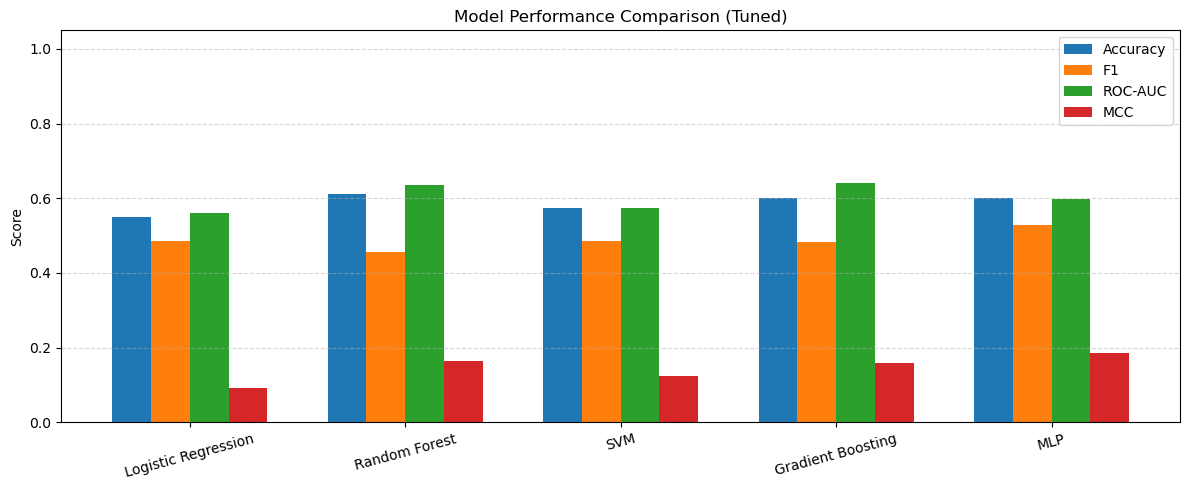

In [24]:
# 그래프 1 — 모델별 성능 지표 막대 그래프 비교

metrics = ["Accuracy", "F1", "ROC-AUC", "MCC"]
model_names = tuned_df["Model"].tolist()

x = range(len(model_names))
width = 0.18  # 막대 너비

fig, ax = plt.subplots(figsize=(12, 5))

for i, metric in enumerate(metrics):
    values = tuned_df[metric].tolist()
    offset = (i - len(metrics) / 2) * width + width / 2
    ax.bar([xi + offset for xi in x], values, width=width, label=metric)

ax.set_xticks(list(x))
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison (Tuned)")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

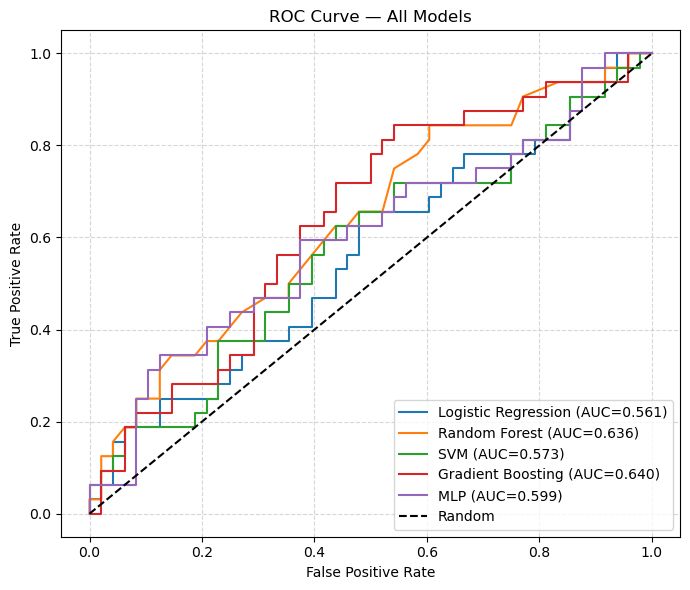

In [25]:
# 그래프 2 — ROC Curve
# AUC(면적)가 클수록 좋은 모델

fig, ax = plt.subplots(figsize=(7, 6))

for name, model in best_models.items():
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

# 기준선 (랜덤 분류기)
ax.plot([0, 1], [0, 1], "k--", label="Random")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — All Models")
ax.legend(loc="lower right")
ax.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

최종 선택 모델: MLP
  MCC=0.1846, F1=0.5294, ROC-AUC=0.5990


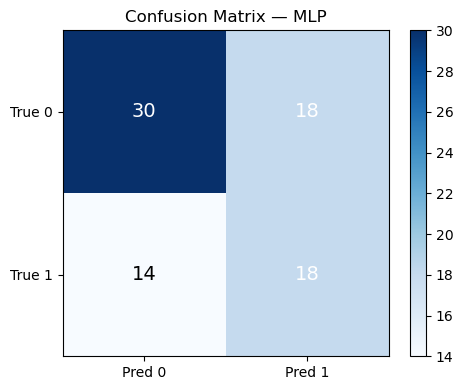

In [26]:
# 그래프 3 — 최종 선택 모델의 Confusion Matrix
# Confusion Matrix: 예측이 실제와 얼마나 일치하는지
#   TN(왼쪽 위) = 음성을 음성으로 정확히 예측
#   TP(오른쪽 아래) = 양성을 양성으로 정확히 예측
#   FP(오른쪽 위) = 음성인데 양성으로 잘못 예측
#   FN(왼쪽 아래) = 양성인데 음성으로 잘못 예측

# MCC가 가장 높은 모델을 최종 모델로 선택
best_row = tuned_df.sort_values("MCC", ascending=False).iloc[0]
best_name = best_row["Model"]
best_model = best_models[best_name]

print(f"최종 선택 모델: {best_name}")
print(f"  MCC={best_row['MCC']:.4f}, F1={best_row['F1']:.4f}, ROC-AUC={best_row['ROC-AUC']:.4f}")

pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, pred_best)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticklabels(["True 0", "True 1"])
ax.set_title(f"Confusion Matrix — {best_name}")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

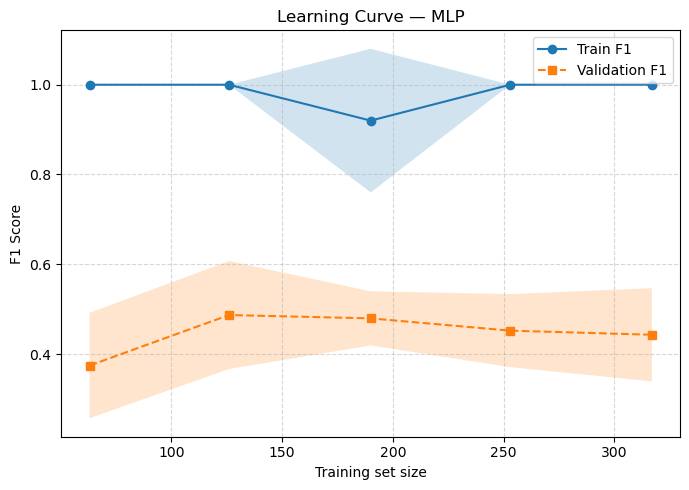

In [27]:
# 그래프 4 — Learning Curve
# 훈련 데이터가 늘어날수록 모델 성능이 어떻게 바뀌는지
# train score와 validation score의 차이가 크면 과적합 신호

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X, y,
    cv=5,
    scoring="f1",
    train_sizes=[0.2, 0.4, 0.6, 0.8, 1.0],
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(train_sizes, train_mean, "o-", label="Train F1")
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std, alpha=0.2)

ax.plot(train_sizes, val_mean, "s--", label="Validation F1")
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std, alpha=0.2)

ax.set_xlabel("Training set size")
ax.set_ylabel("F1 Score")
ax.set_title(f"Learning Curve — {best_name}")
ax.legend()
ax.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

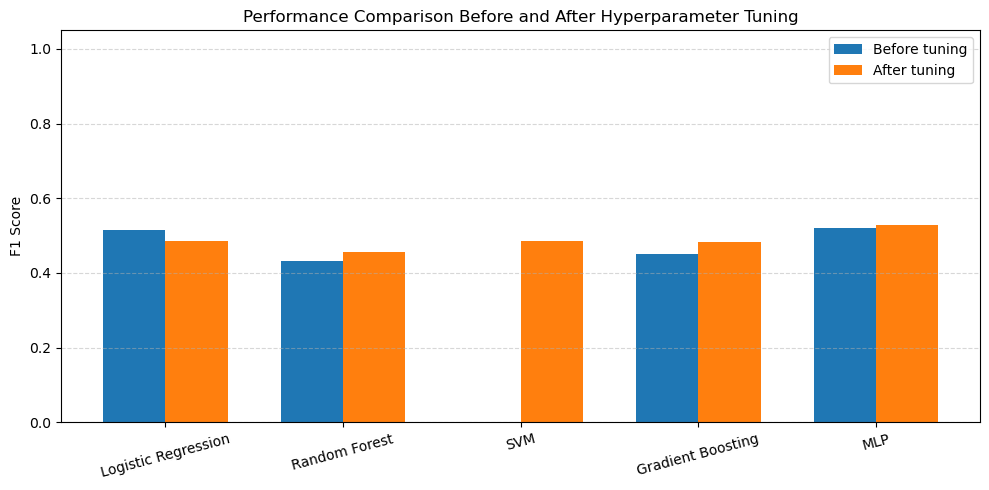

In [28]:
# 그래프 5 — 튜닝 전후 성능 비교
# hyperparameter 탐색이 실제로 성능을 얼마나 올렸는지 확인
# 파란 막대 = 튜닝 전, 주황 막대 = 튜닝 후

metric = "F1"
model_names = tuned_df["Model"].tolist()

before_scores = basic_result.set_index("Model").loc[model_names, metric].tolist()
after_scores  = tuned_df.set_index("Model").loc[model_names, metric].tolist()

x = range(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar([xi - width/2 for xi in x], before_scores, width=width, label="Before tuning")
ax.bar([xi + width/2 for xi in x], after_scores,  width=width, label="After tuning")

ax.set_xticks(list(x))
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylabel("F1 Score")
ax.set_title("Performance Comparison Before and After Hyperparameter Tuning")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# SVM 모델의 Before tuning 막대가 없는 이유
# : 튜닝 전엔 SVM 모델의 성능이(Sensitivity, F1, MCC) 0으로 나타남 -> 모델이 모든 샘플을 음성 클래스(0)로만 예측하고 있었음

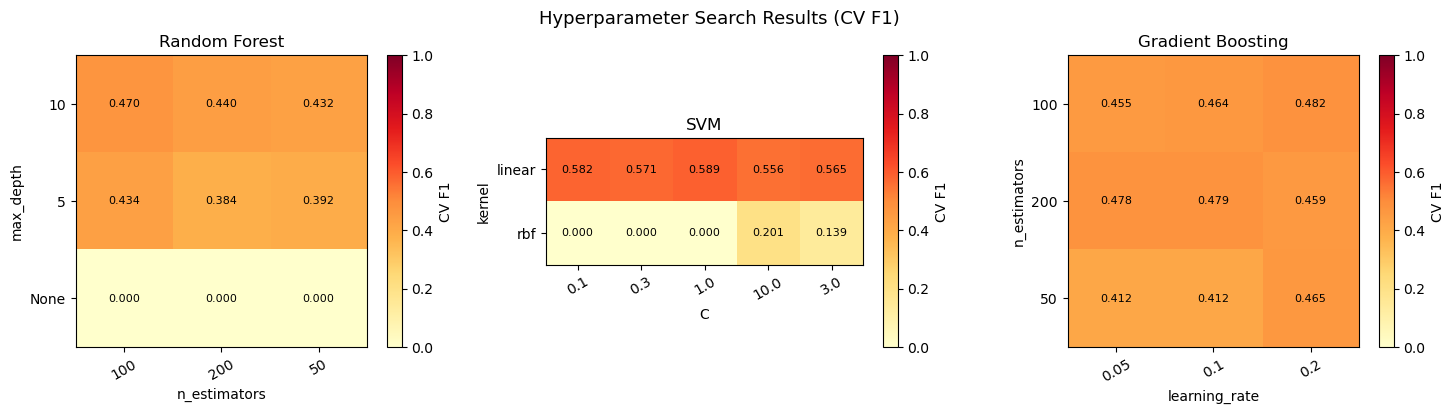

In [29]:
# 그래프 6 — Hyperparameter Heatmap
# 파라미터 조합별 CV F1 점수를 색으로 보여줍니다.
# 파라미터가 2개인 RF, SVM, GB, MLP에 대해 그립니다.

import numpy as np

grid_list = [
    ("Random Forest",     grid_rf,  "n_estimators", "max_depth"),
    ("SVM",               grid_svm, "C",             "kernel"),
    ("Gradient Boosting", grid_gb,  "learning_rate", "n_estimators"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, grid, param1, param2) in zip(axes, grid_list):

    # GridSearchCV 결과를 데이터프레임으로 변환
    cv_df = pd.DataFrame(grid.cv_results_)

    p1_vals = sorted(cv_df[f"param_{param1}"].unique(), key=lambda x: str(x))
    p2_vals = sorted(cv_df[f"param_{param2}"].unique(), key=lambda x: str(x))

    # 히트맵용 2D 배열 만들기
    matrix = []
    for p2 in p2_vals:
        row = []
        for p1 in p1_vals:
            mask = (cv_df[f"param_{param1}"] == p1) & (cv_df[f"param_{param2}"] == p2)
            score = cv_df.loc[mask, "mean_test_score"].values
            row.append(score[0] if len(score) > 0 else 0)
        matrix.append(row)

    matrix = np.array(matrix)

    im = ax.imshow(matrix, cmap="YlOrRd", vmin=0, vmax=1)

    ax.set_xticks(range(len(p1_vals)))
    ax.set_xticklabels([str(v) for v in p1_vals], rotation=30)
    ax.set_yticks(range(len(p2_vals)))
    ax.set_yticklabels([str(v) for v in p2_vals])
    ax.set_xlabel(param1)
    ax.set_ylabel(param2)
    ax.set_title(f"{name}")

    # 각 칸에 숫자 표시
    for i in range(len(p2_vals)):
        for j in range(len(p1_vals)):
            ax.text(j, i, f"{matrix[i, j]:.3f}",
                    ha="center", va="center", fontsize=8,
                    color="black" if matrix[i, j] < 0.7 else "white")

    fig.colorbar(im, ax=ax, label="CV F1")

plt.suptitle("Hyperparameter Search Results (CV F1)", fontsize=13)
plt.tight_layout()
plt.show()

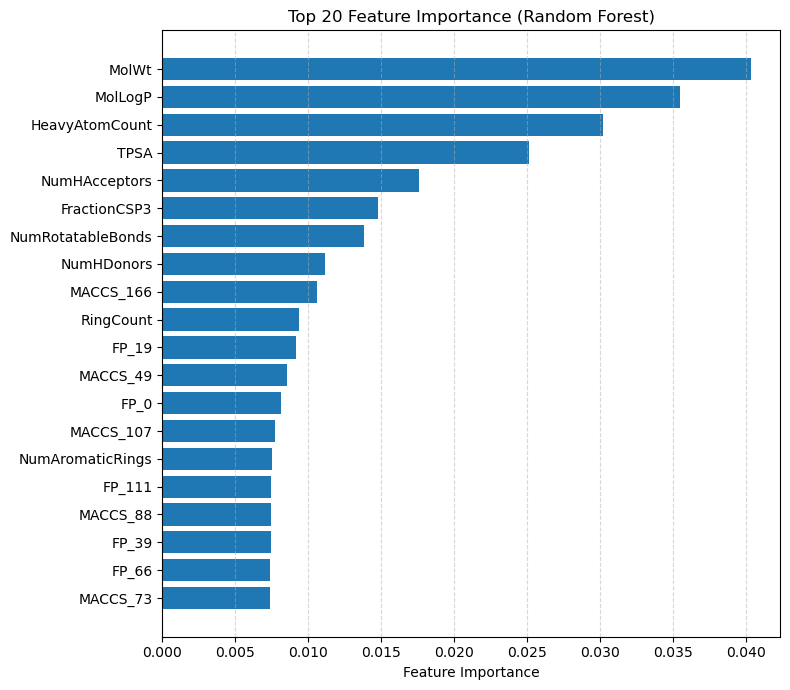

In [30]:
# 그래프 7 — Feature Importance (Random Forest)
# Random Forest는 각 feature가 예측에 얼마나 기여했는지 점수를 자동으로 계산
# 점수가 높을수록 그 descriptor가 발암성 예측에 중요하다는 뜻

rf_best = grid_rf.best_estimator_

# feature 이름과 중요도 점수를 데이터프레임으로 정리
importance_df = pd.DataFrame({
    "feature":    feature_cols,
    "importance": rf_best.feature_importances_,
})

# 중요도 높은 순서로 정렬하고 상위 20개만 선택
importance_df = importance_df.sort_values("importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))

ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
ax.set_xlabel("Feature Importance")
ax.set_title("Top 20 Feature Importance (Random Forest)")
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

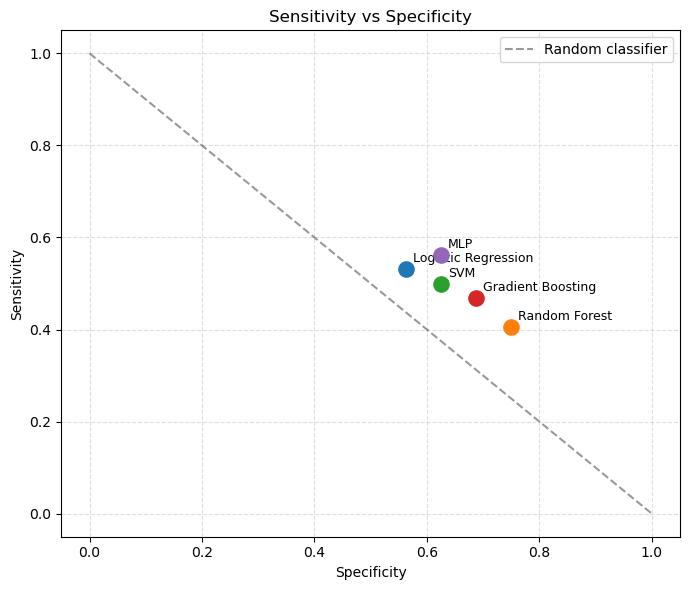

In [31]:
# 그래프 8 — Sensitivity vs Specificity 산점도
# Sensitivity : 실제 양성(발암성)을 얼마나 잘 잡는지
# Specificity : 실제 음성을 얼마나 잘 잡는지
# 두 값이 모두 높은 모델이 가장 이상적 (오른쪽 위 모서리에 가까울수록 좋음)

fig, ax = plt.subplots(figsize=(7, 6))

for row in tuned_df.itertuples():
    ax.scatter(row.Specificity, row.Sensitivity, s=120, zorder=3)
    ax.annotate(
        row.Model,
        xy=(row.Specificity, row.Sensitivity),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

# 기준선: 랜덤 분류기 (대각선)
ax.plot([0, 1], [1, 0], "k--", alpha=0.4, label="Random classifier")

ax.set_xlabel("Specificity")
ax.set_ylabel("Sensitivity")
ax.set_title("Sensitivity vs Specificity")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 모델 저장 & 새 분자 예측

최고 성능 모델을 파일로 저장한 뒤, 새로운 분자 구조(SMILES)를 입력받아 예측

In [32]:
# 저장할 때 어떤 feature를 사용했는지도 함께 저장해 나중에 새 분자를 예측할 때 같은 feature를 계산할 수 있도록 함

import joblib

save_package = {
    "model":        best_model,       # 학습된 모델
    "feature_cols": feature_cols,     # 사용한 feature 이름 목록
    "best_name":    best_name,        # 모델 이름 (확인용)
}

joblib.dump(save_package, "model_best.joblib")
print("model_best.joblib 저장 완료")
print(f"저장된 모델: {best_name}")
print(f"feature 수: {len(feature_cols)}")

model_best.joblib 저장 완료
저장된 모델: MLP
feature 수: 305


In [33]:
# 새로운 분자 SMILES를 입력하면 발암성 예측 결과를 돌려주는 함수

from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, MACCSkeys
from rdkit import DataStructs
import numpy as np
import pandas as pd

def predict_new_molecule(smiles, package_path="model_best.joblib"):
    """
    SMILES 문자열을 입력받아 발암성 예측 결과를 반환합니다.

    Parameters
    ----------
    smiles : str
        예측할 분자의 SMILES 코드
    package_path : str
        저장된 모델 파일 경로

    Returns
    -------
    없음 (결과를 출력합니다)
    """
    # 1. 저장된 모델 불러오기
    package = joblib.load(package_path)
    model = package["model"]
    feature_cols = package["feature_cols"]

    # 2. SMILES → RDKit 분자 객체 변환
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print("오류: 유효하지 않은 SMILES입니다.")
        return

    # 3. Descriptor 계산 (template1과 동일한 순서)
    descriptor_funcs = {
        "MolWt":             Descriptors.MolWt,
        "MolLogP":           Descriptors.MolLogP,
        "TPSA":              Descriptors.TPSA,
        "RingCount":         Descriptors.RingCount,
        "NumHDonors":        Descriptors.NumHDonors,
        "NumHAcceptors":     Descriptors.NumHAcceptors,
        "NumRotatableBonds": Descriptors.NumRotatableBonds,
        "FractionCSP3":      Descriptors.FractionCSP3,
        "NumAromaticRings":  Descriptors.NumAromaticRings,
        "HeavyAtomCount":    Descriptors.HeavyAtomCount,
    }
    desc_values = {name: func(mol) for name, func in descriptor_funcs.items()}

    # 4. Morgan fingerprint (128 bits)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=128)
    fp_arr = np.zeros((128,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, fp_arr)
    fp_values = {f"FP_{i}": fp_arr[i] for i in range(128)}

    # 5. MACCS keys (167 bits)
    maccs = MACCSkeys.GenMACCSKeys(mol)
    maccs_arr = np.zeros((167,), dtype=int)
    DataStructs.ConvertToNumpyArray(maccs, maccs_arr)
    maccs_values = {f"MACCS_{i}": maccs_arr[i] for i in range(167)}

    # 6. 모든 feature를 하나의 행으로 합치기
    all_features = {**desc_values, **fp_values, **maccs_values}
    row = pd.DataFrame([all_features])[feature_cols]

    # 7. 예측
    pred_label = model.predict(row)[0]
    pred_prob  = model.predict_proba(row)[0][1]

    # 8. 결과 출력
    print(f"입력 SMILES : {smiles}")
    print(f"예측 라벨   : {pred_label}  (0 = No evidence, 1 = Carcinogenic)")
    print(f"발암성 확률 : {pred_prob:.4f}")

In [34]:
# 예시 — 벤젠(benzene)과 에탄올(ethanol)을 예측해봅니다.

# 벤젠: 알려진 발암물질
predict_new_molecule("c1ccccc1")

print()

# 에탄올: 상대적으로 낮은 발암성
predict_new_molecule("CCO")

입력 SMILES : c1ccccc1
예측 라벨   : 1  (0 = No evidence, 1 = Carcinogenic)
발암성 확률 : 0.9408

입력 SMILES : CCO
예측 라벨   : 0  (0 = No evidence, 1 = Carcinogenic)
발암성 확률 : 0.1112


[17:24:06] DEPRECATION WARNING: please use MorganGenerator
[17:24:06] DEPRECATION WARNING: please use MorganGenerator
